In [1]:
import sys
from os.path import dirname, realpath, join
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import kendalltau

from Functions.method_exp import PDRankSolver
from Functions.data_handle import Data
from Functions.data_handle_exp import DataExp
from tqdm.auto import tqdm

In [2]:
m = 30 # number of items
n_std_trial = np.linspace(0.3, 15, num=20, endpoint=True)
n_simulation_per_trial = 20

# Parameters for data generation
noise_type = 'constant' # type of noise in labels: 'constant', 'None' (no noise), 'BTL' (Bradley-Terry-Luce model)
noise_level = 0.1 # level of noise for noise_type = 'constant'
connectivity ='connected' # graph connective enforced: 'no', 'connected', 'strongly'
bt_interval = None # scores interval for BTL model

# Parameters for PD-Rank (additional parameters can be consulted in the PDRank class. We recommend using the default values)
epsilon_out = 1e-2 # epsilon for stopping criterion of outer iterations. Recommended values of 1e-2 for m<500, 1e-1 otherwise
epsilon_in  = 1e-2 # epsilon for stopping criterion of inner iterations. Recommended values of 1e-2 for m<500, 1e-3 otherwise

In [25]:
def run_simulation(m,
                   n_pairs,
                   noise_type, 
                   noise_level, 
                   connectivity='connected', 
                   bt_interval=None, 
                   epsilon_out=1e-2, 
                   epsilon_in=1e-2,
                   return_data=False,
                   return_solution_path=False):
    config = {
        'm': m,
        'n_pairs': n_pairs,
        'noise_type': noise_type,
        'noise_level': noise_level,
        'connectivity': connectivity,
        'bt_interval': bt_interval,
        'epsilon_out': epsilon_out,
        'epsilon_in': epsilon_in,
    }
    # Generate comparison data with the required parameters
    data = DataExp(m,n_pairs,noise_type=noise_type,noise_level=noise_level, connectivity=connectivity,
                            bt_interval = bt_interval, demo=False)
                
    # If the connectivity is not None, the generated data may have a different number of items and comparisons
    real_m, real_n = data.m, data.n 
    x_gt = data.x # ground truth item scores
    x_gt_ranking = np.argsort(x_gt) # ground truth ranking

    # Data may be obtained in different formats (see methods in data_handle.py)
    # PD-Rank requires a matrix A with n rows and m columns, where n is the number of comparisons and m is the number of items.
    # Each row indicates a comparison between two items: with ones in the columns of the items being compared and zeros elsewhere.
    # The weights w_obs are the observed weights of the comparisons. I.e., the number of times each comparison was observed.
    # This only works if annotated behaviour is not included, as all observations of the same pair are aggregated for speed purposes.
    # If the annotated behaviour is desired, a different method must be implemented.
    if noise_type != 'random_annotator':
        A, w_obs = data.get_Areduced_w()
    else:
        A = data.get_A_full()
        w_obs = None
    pdrank = PDRankSolver(epsilon_in=epsilon_in, epsilon_out=epsilon_out)
    x = pdrank.solve(A, w_obs=w_obs, return_solution_path=return_solution_path) # solve the problem
        
    if return_solution_path:
        x, ws, xs = x
    x_pdrank_ranking = np.argsort(x) # ranking obtained by pdrank
    # Calculate Kendall's tau
    kendall_tau = kendalltau(x_gt, x).statistic
    config['kendall_tau'] = kendall_tau
    
    if not return_data and not return_solution_path:
        return config
        
    returns = [config]
    if return_data:
        returns.append(data)
    if return_solution_path:
        returns.append(ws)
        returns.append(xs)
        
    return tuple(returns)

In [26]:
%%time
run_simulation(m,
                   1000,
                   noise_type, 
                   noise_level, 
                   connectivity, 
                   bt_interval, 
                   epsilon_out, 
                   epsilon_in)

CPU times: user 72.1 ms, sys: 575 µs, total: 72.7 ms
Wall time: 71.1 ms


{'m': 30,
 'n_pairs': 1000,
 'noise_type': 'constant',
 'noise_level': 0.1,
 'connectivity': 'connected',
 'bt_interval': None,
 'epsilon_out': 0.01,
 'epsilon_in': 0.01,
 'kendall_tau': np.float64(0.9494252873563218)}

In [8]:
def run_exp(m, n_std_trial, n_simulation_per_trial, **kwargs):
    noise_type = kwargs.get('noise_type', 'constant')
    noise_level = kwargs.get('noise_level', 0.1)
    connectivity = kwargs.get('connectivity', 'connected')
    bt_interval = kwargs.get('bt_interval', None) # scores interval for BTL model
    
    # Parameters for PD-Rank (additional parameters can be consulted in the PDRank class. We recommend using the default values)
    epsilon_out = kwargs.get('epsilon_out', 1e-2)
    epsilon_in  = kwargs.get('epsilon_in', 1e-2)
    
    n_comparisons = (n_std_trial*m*(m-1)/2).astype(int) # number of comparisons
    result = []
    for i, n_pairs in enumerate(tqdm(n_comparisons)):
        for j in range(n_simulation_per_trial):
            res = run_simulation(m, n_pairs, noise_type, 
                   noise_level, 
                   connectivity, 
                   bt_interval, 
                   epsilon_out, 
                   epsilon_in)
            result.append(res)
    return result

In [9]:
from joblib import Parallel, delayed
# Parallel version of run_exp (for speed purpose)
def run_exp_parallel(m, n_std_trial, n_simulation_per_trial, **kwargs):
    noise_type = kwargs.get('noise_type', 'constant')
    noise_level = kwargs.get('noise_level', 0.1)
    connectivity = kwargs.get('connectivity', 'connected')
    bt_interval = kwargs.get('bt_interval', None) # scores interval for BTL model
    
    # Parameters for PD-Rank (additional parameters can be consulted in the PDRank class. We recommend using the default values)
    epsilon_out = kwargs.get('epsilon_out', 1e-2)
    epsilon_in  = kwargs.get('epsilon_in', 1e-2)
    
    n_comparisons = (n_std_trial*m*(m-1)/2).astype(int) # number of comparisons
    result = Parallel(n_jobs=4, verbose=10)(delayed(run_simulation)(m, n_pairs, noise_type, 
                   noise_level, 
                   connectivity, 
                   bt_interval, 
                   epsilon_out, 
                   epsilon_in) for _ in range(n_simulation_per_trial) for n_pairs in n_comparisons)
    return result

In [15]:
# Can use the sequential version run_exp if you don't have joblib
configs = [
    {"noise_type": 'constant', "noise_level": 0.1},
    {"noise_type": 'random_annotator', "noise_level": np.array([0.1, 0.15, 0.2, 0.175])}
]
results = []
for config in configs:
    result = run_exp_parallel(m, n_std_trial, n_simulation_per_trial, **config)
    results.append(pd.DataFrame(result))

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   5 tasks      | elapsed:    1.4s
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:    1.6s
[Parallel(n_jobs=4)]: Done  17 tasks      | elapsed:    1.9s
[Parallel(n_jobs=4)]: Done  24 tasks      | elapsed:    2.1s
[Parallel(n_jobs=4)]: Done  33 tasks      | elapsed:    2.5s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    2.9s
[Parallel(n_jobs=4)]: Done  53 tasks      | elapsed:    3.4s
[Parallel(n_jobs=4)]: Done  64 tasks      | elapsed:    3.8s
[Parallel(n_jobs=4)]: Done  77 tasks      | elapsed:    4.3s
[Parallel(n_jobs=4)]: Done  90 tasks      | elapsed:    4.7s
[Parallel(n_jobs=4)]: Done 105 tasks      | elapsed:    5.4s
[Parallel(n_jobs=4)]: Done 120 tasks      | elapsed:    5.9s
[Parallel(n_jobs=4)]: Done 137 tasks      | elapsed:    6.6s
[Parallel(n_jobs=4)]: Done 154 tasks      | elapsed:    7.2s
[Parallel(n_jobs=4)]: Done 173 tasks      | elapsed:    7.9s
[Parallel(

Text(0, 0.5, "Kendall's tau")

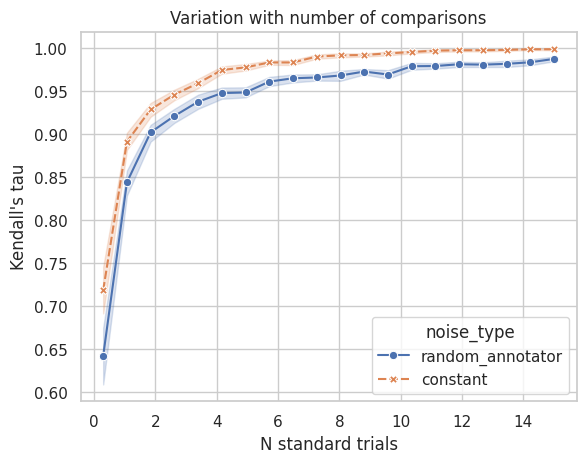

In [16]:
df = pd.concat(results).sort_values(by='n_pairs')
df['n_std_trial'] = df['n_pairs'] * 2 / (m*(m-1))
sns.set(style="whitegrid")
g = sns.lineplot(data=df, x='n_std_trial', y='kendall_tau', hue='noise_type', style='noise_type', markers=True)
g.set_title('Variation with number of comparisons')
g.set_xlabel("N standard trials")
g.set_ylabel("Kendall's tau")

In [17]:
g.get_figure().savefig('test_rnd_annotator_result.pdf', format='pdf', bbox_inches='tight')

In [20]:
num_std_trial = 3
config, data, ws, xs = run_simulation(m,
                   int(num_std_trial * m * (m - 1) / 2),
                   noise_type, 
                   noise_level, 
                   connectivity, 
                   bt_interval, 
                   epsilon_out, 
                   epsilon_in, return_data=True, return_solution_path=True)
config['kendall_tau']

np.float64(0.9632183908045978)

In [21]:
A, w_obs = data.get_Areduced_w()
noisy_idx = np.nonzero(A @ data.x < 0)[0]
A.shape

(519, 30)

In [22]:
df = pd.DataFrame(ws.T).reset_index()
df = pd.melt(df, id_vars='index').rename(columns={'index': 'n', 'variable': 'iteration'})
df['noisy'] = df['n'].isin(noisy_idx)
df

,n,iteration,value,noisy
0,0,0,1.000000,False
1,1,0,1.000000,False
2,2,0,1.000000,False
3,3,0,1.000000,False
4,4,0,1.000000,False
...,...,...,...,...
6223,514,11,99.998834,False
6224,515,11,20.388918,False
6225,516,11,0.069323,True
6226,517,11,0.052218,True


In [23]:
# iteration, value, n, noisy?
test_noisy_idx = df[df['noisy'] == True].n.unique().sort()
np.array_equal(test_noisy_idx, noisy_idx.sort())

True

Text(0.5, 1.0, 'Evolution of weight values by outer iteration')

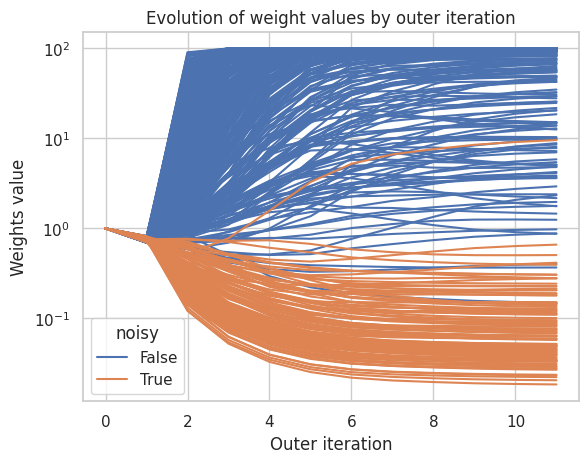

In [24]:
g = sns.lineplot(data=df, x='iteration', y='value', units='n', hue='noisy', 
                 estimator=None)
plt.semilogy()
g.set_xlabel("Outer iteration")
g.set_ylabel("Weights value")
g.set_title("Evolution of weight values by outer iteration")

In [61]:
# For random_annotator noise type
num_std_trial = 3
config, data, ws, xs = run_simulation(m,
                   int(num_std_trial * m * (m - 1) / 2),
                   configs[1]['noise_type'], 
                   configs[1]['noise_level'], 
                    return_data=True, return_solution_path=True)
config['kendall_tau']

np.float64(0.967816091954023)

In [64]:
A, annotators = data.get_A_full(return_annotators=True)
noisy_idx = np.nonzero(A @ data.x < 0)[0]
A.shape, noisy_idx.shape, annotators.shape

((1305, 30), (201,), (1305,))

In [65]:
df = pd.DataFrame(ws.T).reset_index()
# n is the n-th pair
df = pd.melt(df, id_vars='index').rename(columns={'index': 'n', 'variable': 'iteration'})
df['noisy'] = df['n'].isin(noisy_idx)
df['annotator'] = annotators[df['n']]
df

,n,iteration,value,noisy,annotator
0,0,0,1.000000,False,3
1,1,0,1.000000,False,0
2,2,0,1.000000,False,0
3,3,0,1.000000,False,2
4,4,0,1.000000,False,1
...,...,...,...,...,...
15655,1300,11,0.046366,True,2
15656,1301,11,0.052322,True,1
15657,1302,11,0.052322,True,2
15658,1303,11,0.041222,True,3


Text(0.5, 1.0, 'Evolution of weight values by outer iteration')

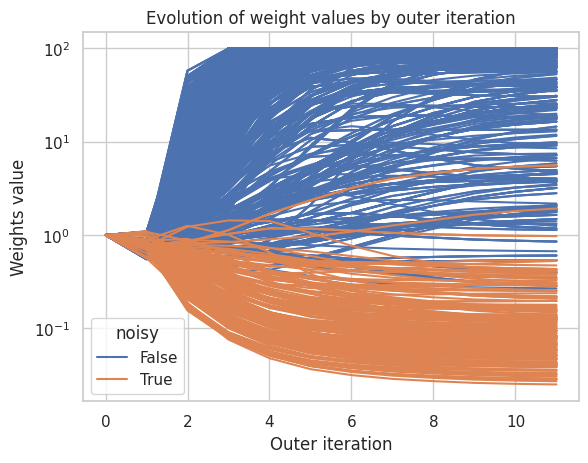

In [66]:
g = sns.lineplot(data=df, x='iteration', y='value', units='n', hue='noisy', 
                 estimator=None)
plt.semilogy()
g.set_xlabel("Outer iteration")
g.set_ylabel("Weights value")
g.set_title("Evolution of weight values by outer iteration")

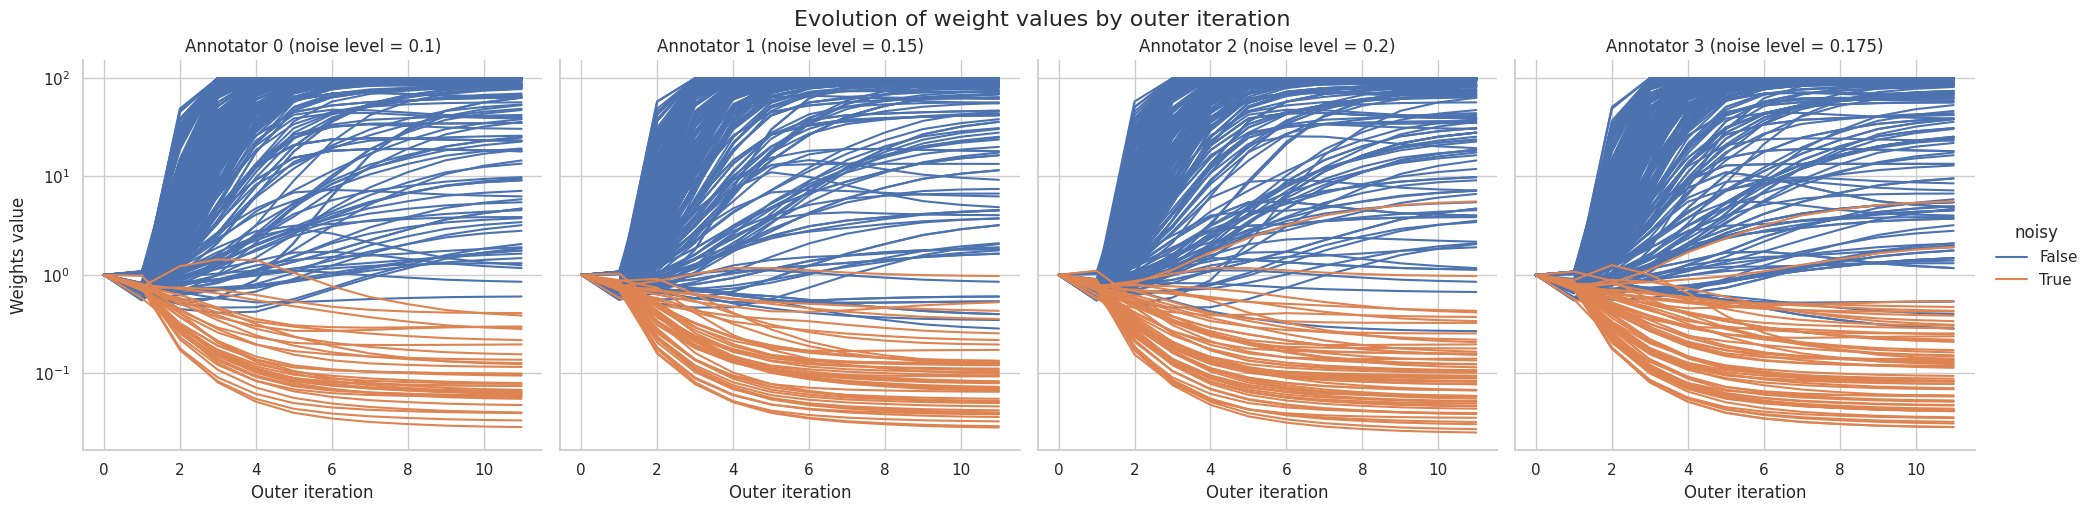

In [67]:
g = sns.relplot(
    data=df, x='iteration', y='value', units='n', hue='noisy',
    col='annotator',
    estimator=None,
    kind="line"
)
plt.semilogy()
g.set_xlabels("Outer iteration")
g.set_ylabels("Weights value")
g.fig.suptitle("Evolution of weight values by outer iteration", fontsize=16, y=1.02)
for col_val, ax in g.axes_dict.items():
    ax.set_title(f"Annotator {col_val} (noise level = {config['noise_level'][col_val]})")